### 【[周末影音解盤](https://www.facebook.com/kevinyang20180801/videos/1228553032028876)】  
本周是2025年第一周開市表現偏弱，而且道瓊指數與標普500指數出現中期空方訊號，周五夜盤期指大漲，明天台股是否有機會跟進補漲？另外，台幣已經貶破長期支撐，下周要趕快站回哪個價位才是安全的？   
完整教學內容，詳見影音解盤~  
https://fb.watch/wVUArpu28S/  

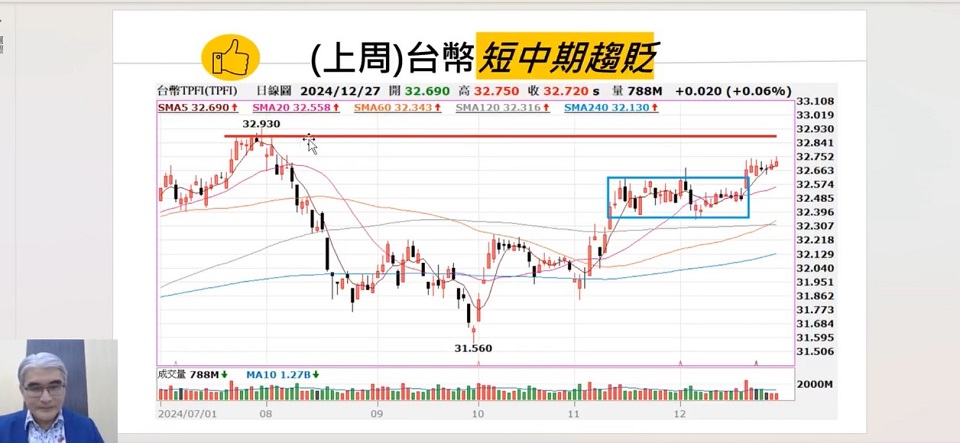  
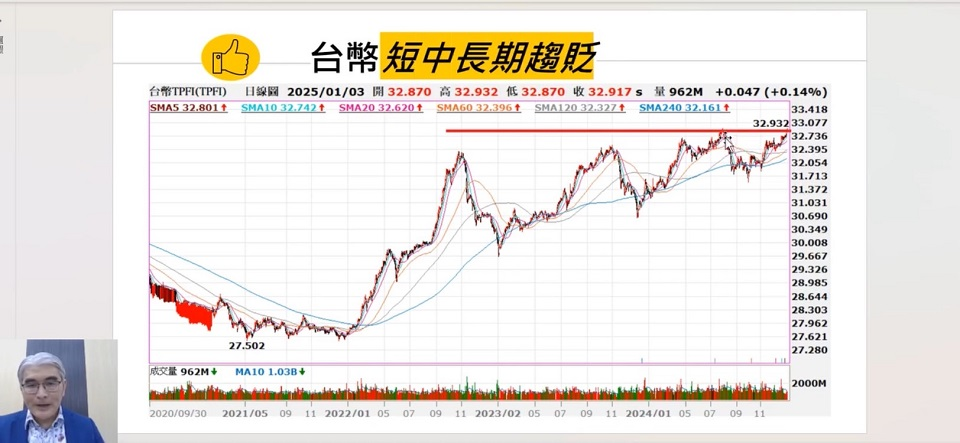  
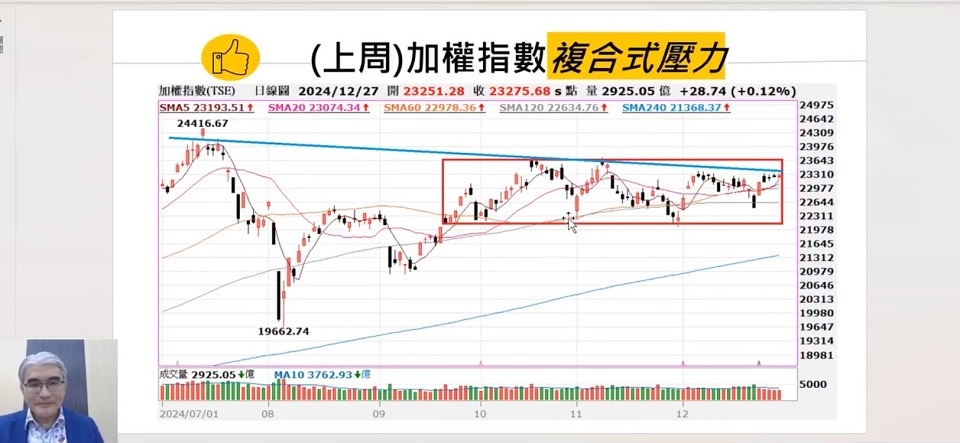  
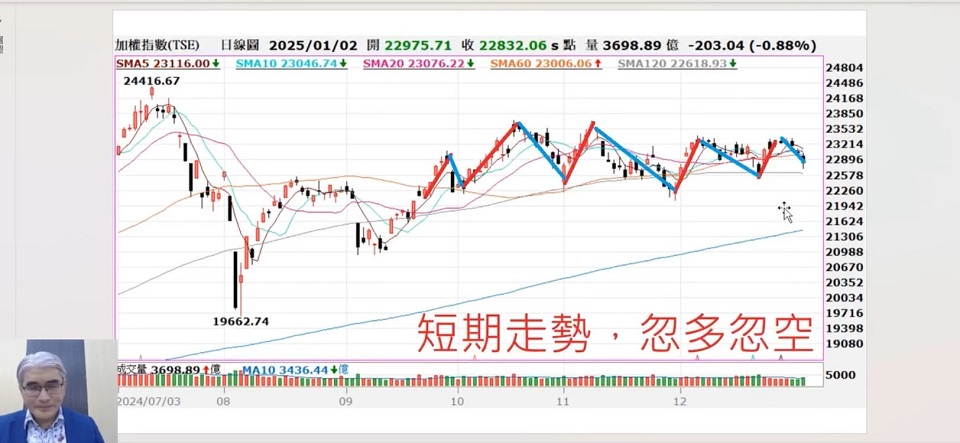  
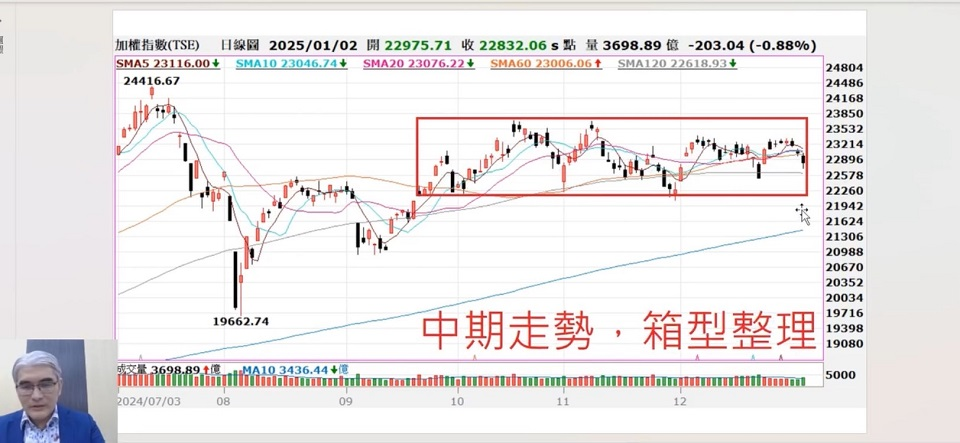  
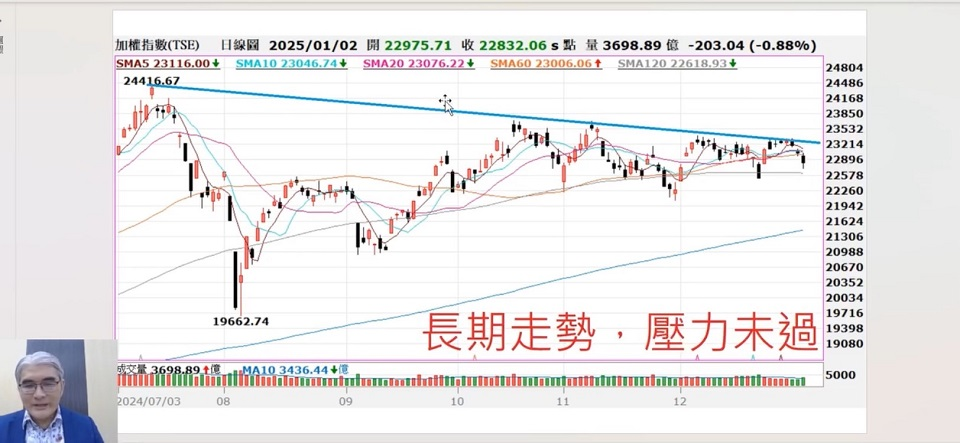  
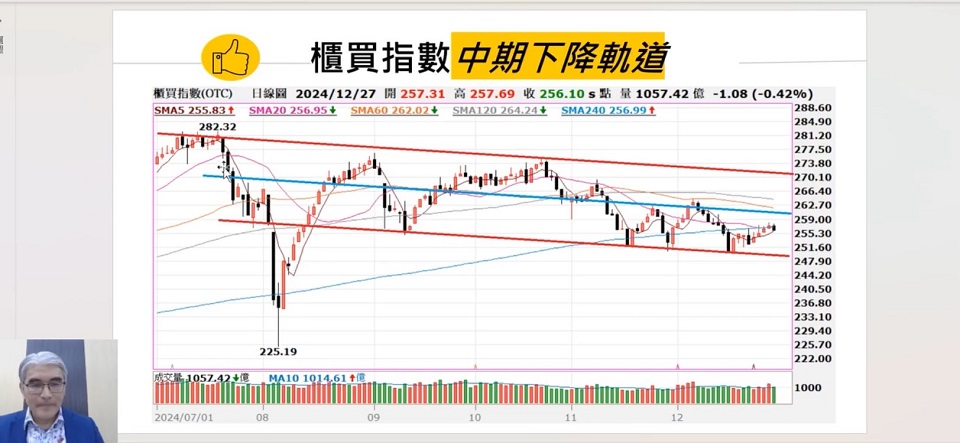  
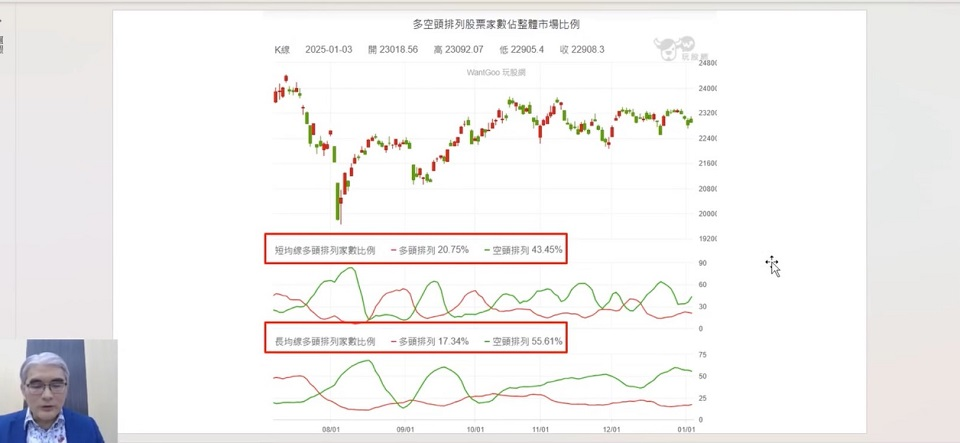  
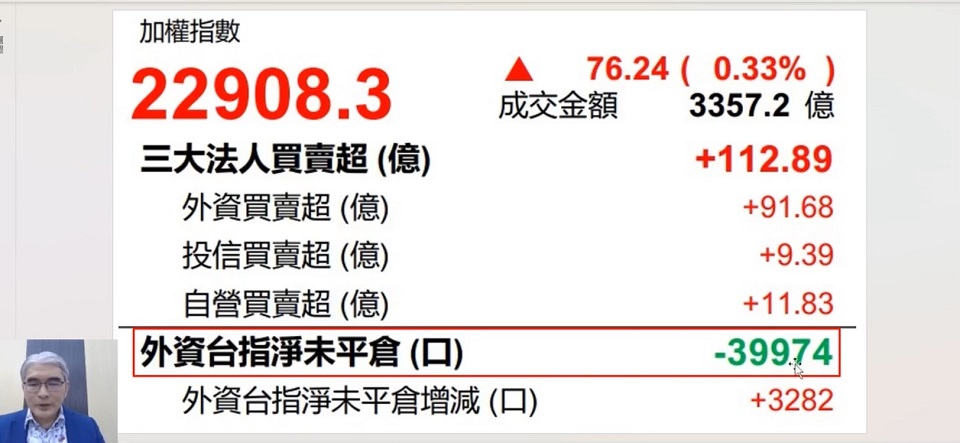  
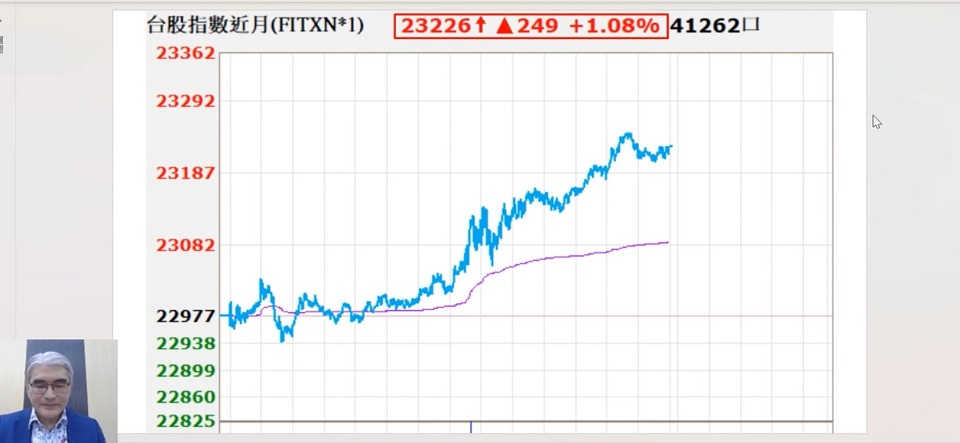  
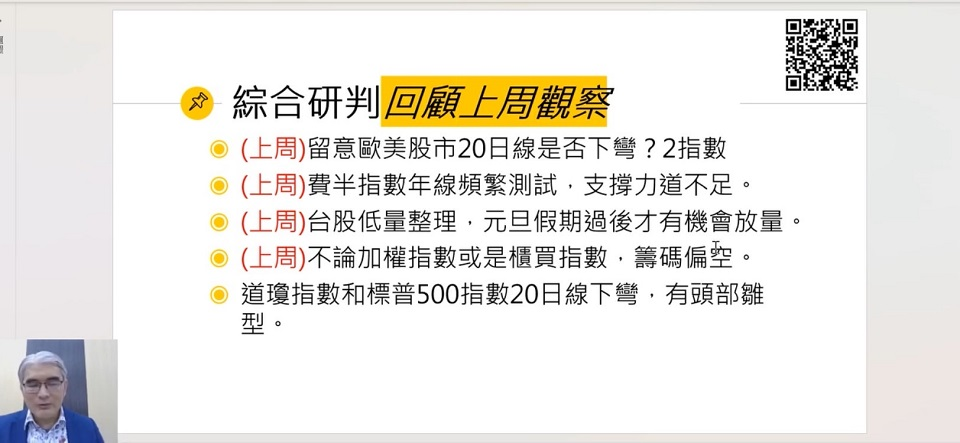  
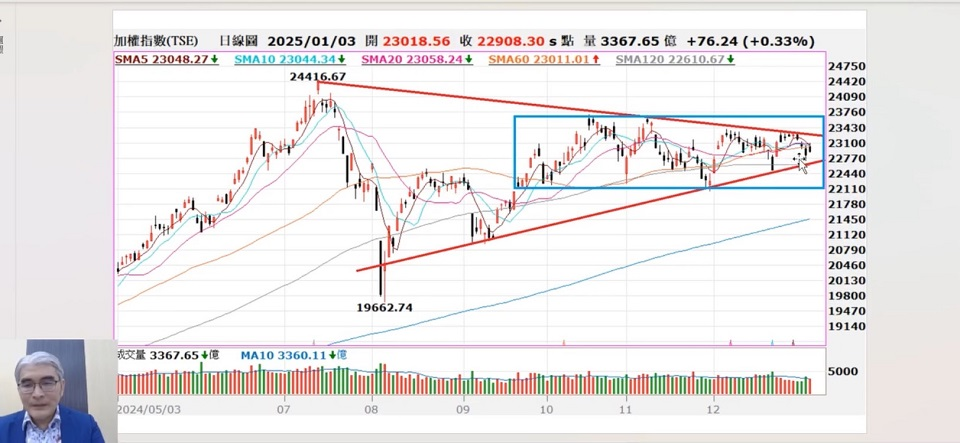  
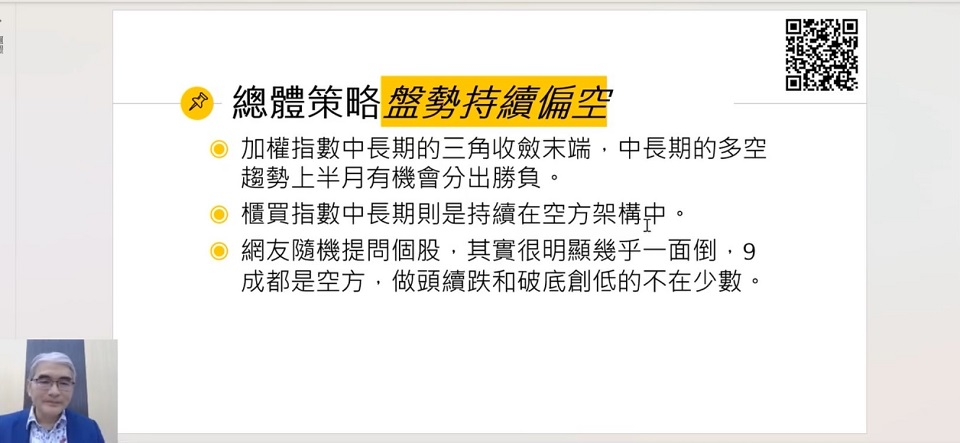  
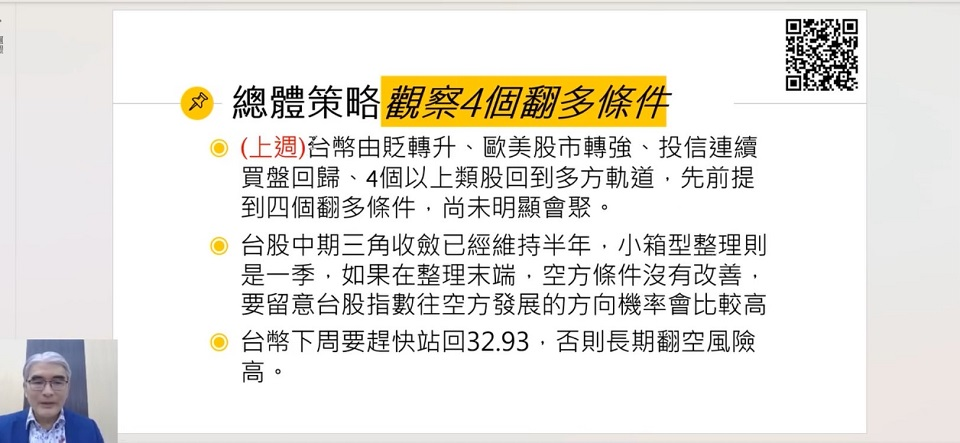  
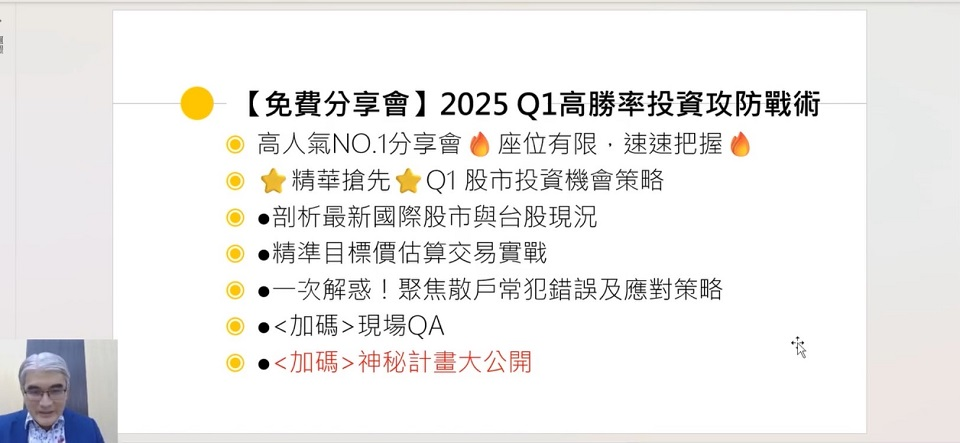  

### [K線捕手](https://www.facebook.com/kevinyang20180801)  
早上有事外出，中午前後才有空，所以比較沒有訊息，行情觀點可以再參考一下昨天的影音解盤。  

[《台北股市》盤中焦點股：台積電、和椿、聯發科、安集、星通、藥華藥](https://tw.stock.yahoo.com/news/%E5%8F%B0%E5%8C%97%E8%82%A1%E5%B8%82-%E7%9B%A4%E4%B8%AD%E7%84%A6%E9%BB%9E%E8%82%A1-%E5%8F%B0%E7%A9%8D%E9%9B%BB-%E5%92%8C%E6%A4%BF-%E8%81%AF%E7%99%BC%E7%A7%91-020545021.html)  

台積電小創高：  
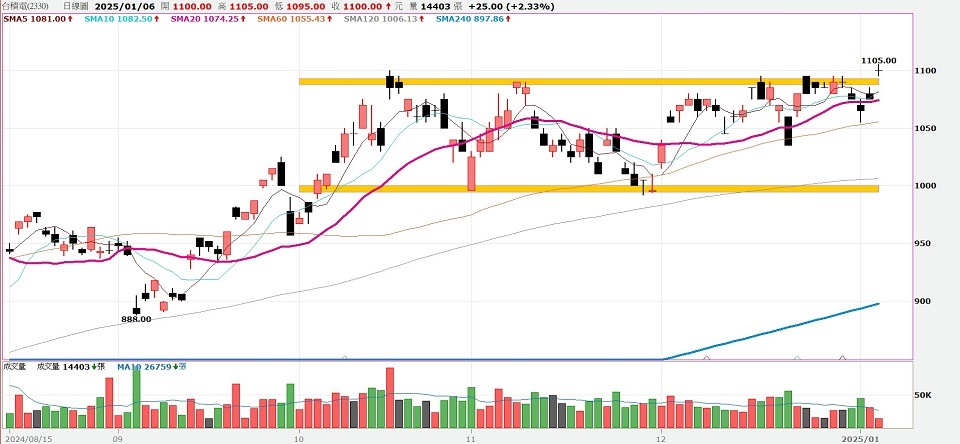  
  
加權與櫃買指數：  
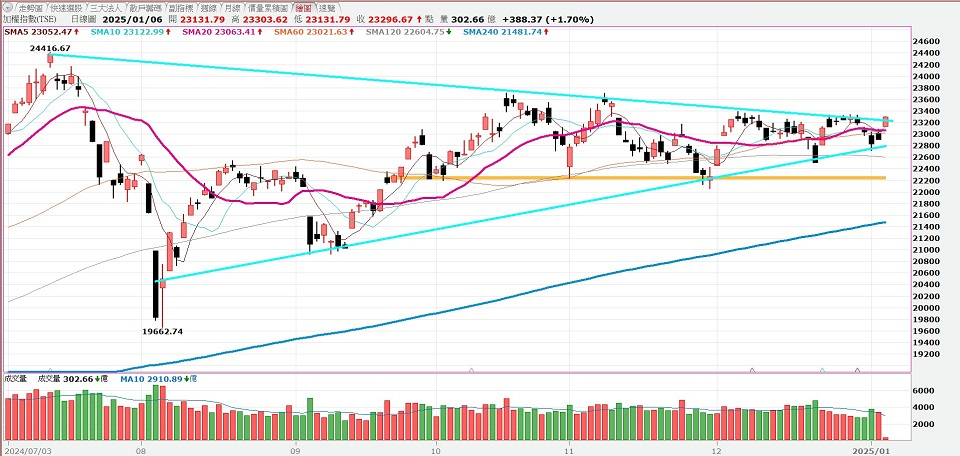  
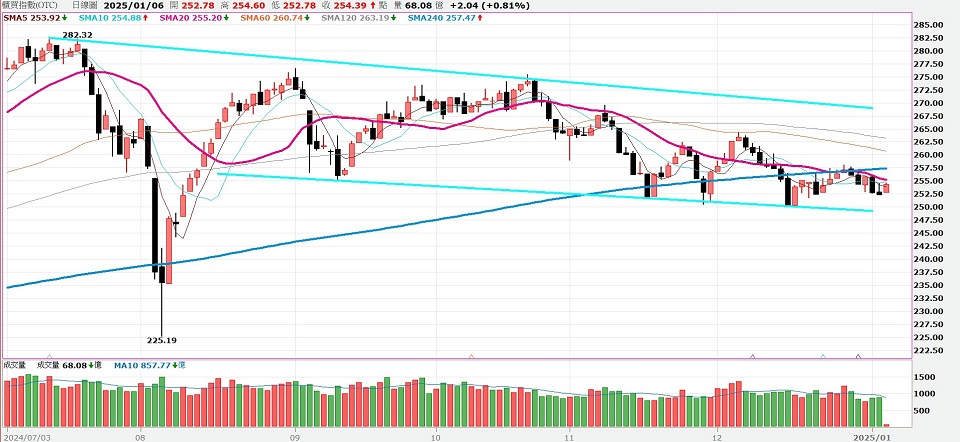  
  
暫時突破壓力區：  
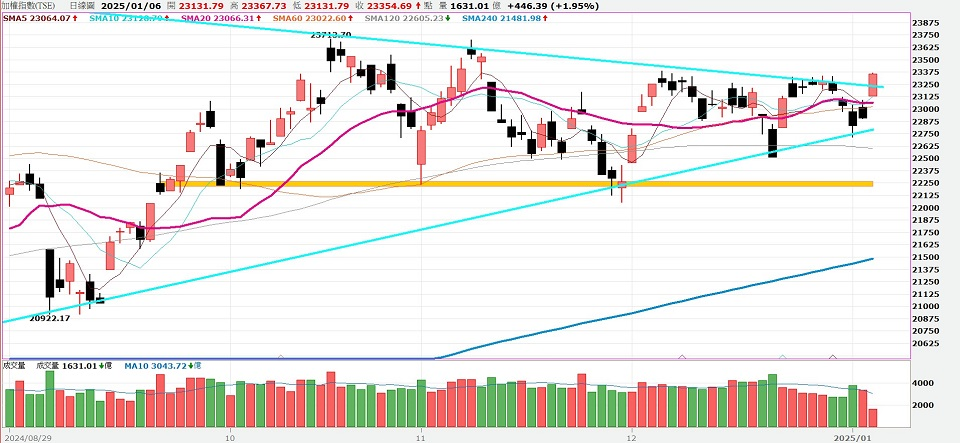  
  
台幣續貶：  
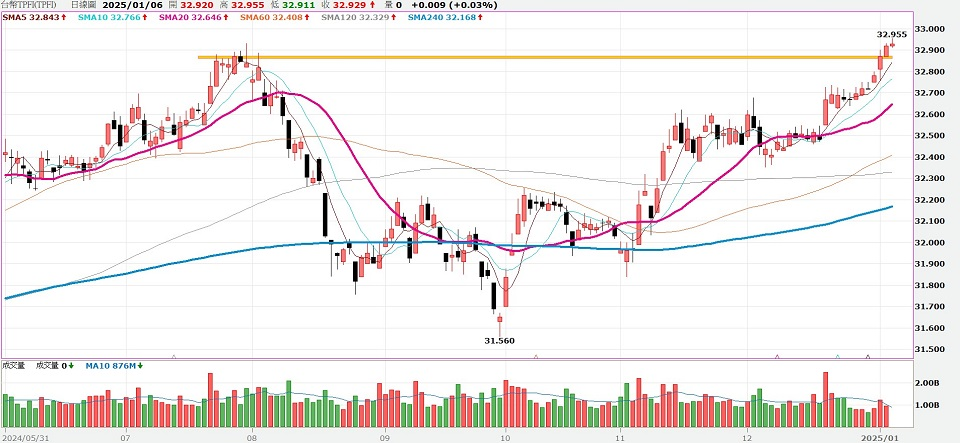  
  
今天台積電大漲創高，帶動台股整體表現，不過台幣趨貶、櫃買指數漲幅相對有限，多空條件雜陳，今天究竟是一日行情？還是重啟多方走勢？目前還沒回到電腦前，剛剛貼圖都是請資深同學幫忙截圖，回到電腦後再幫大家總整理。  
  
加權指數貢獻排行：  
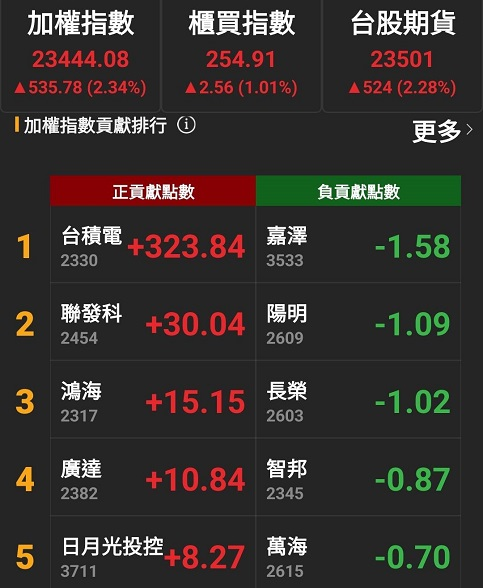  

和康生(1783)  
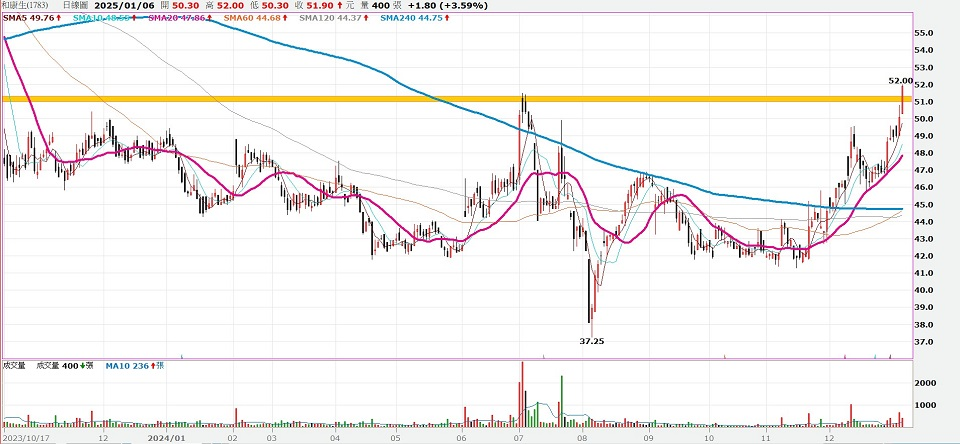  
  
美食-KY(2723)  
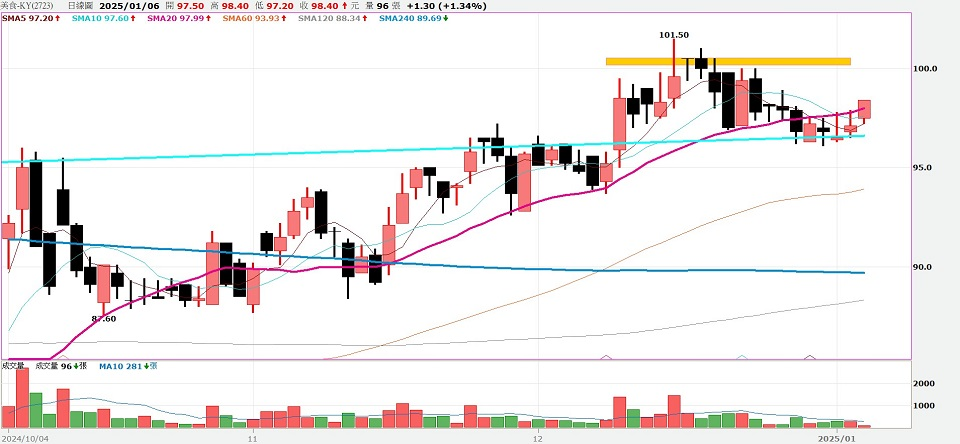  

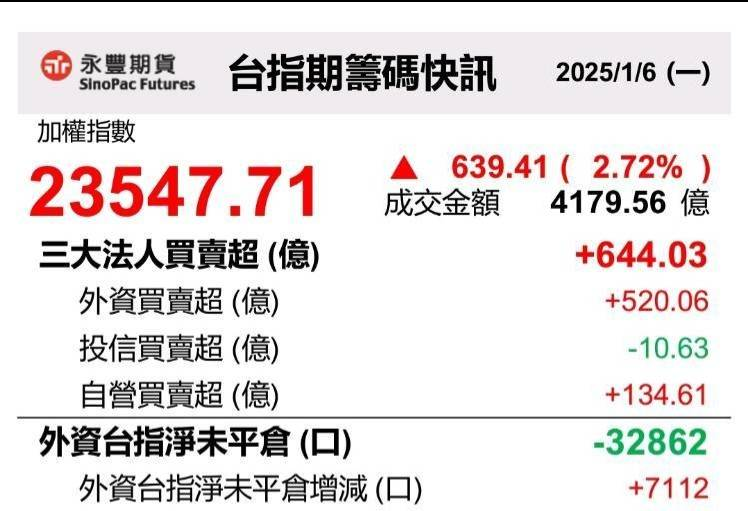  
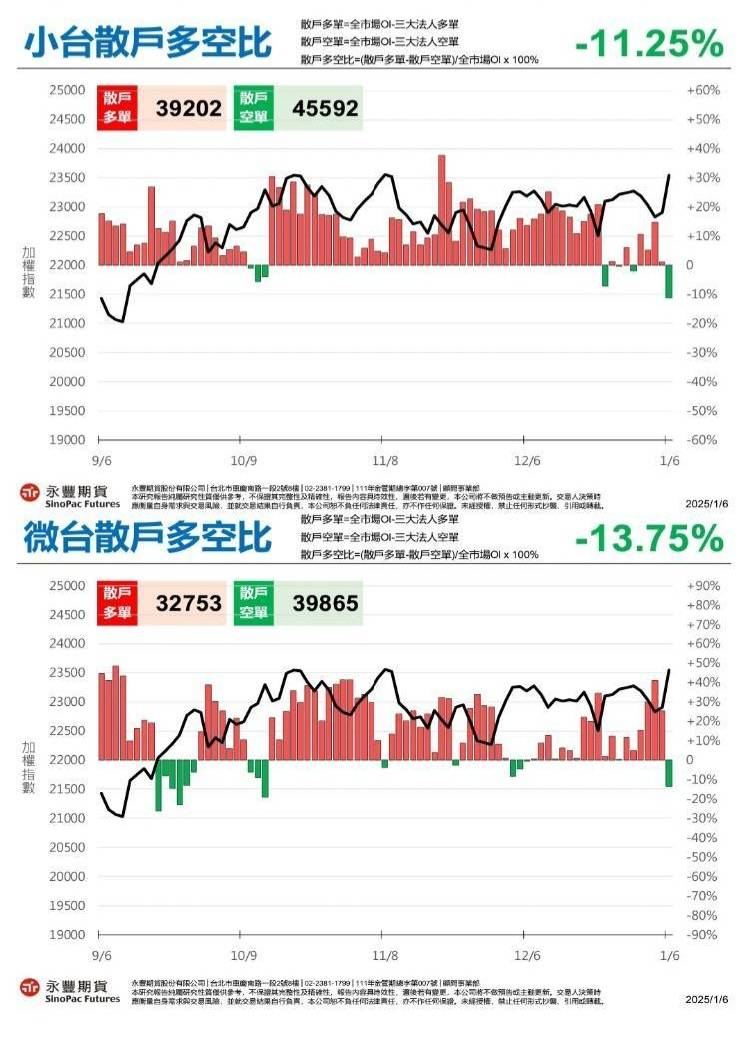  

### 本日進度  
* 調整轉折點偵測程序以進行驗證。  

In [1]:
import pandas as pd
import numpy as np
from scipy.signal import argrelextrema

##### 偵測轉折點函式 #####
# prices    : 價格 (DataFrame)
# mode      : 模式 (str) ： 有'close'、'high_low'與'open_close'三種，預設為'close'
# interval  : 峰到谷或谷到峰之最小間隔 (int) → TODO ： 這邊的設定仍有待檢討
# smoothing : 平滑化參數 （當模式為'close'時有效） (int)
def DetectTurningPoints(prices, mode = 'close', interval = 1, smoothing = 1) :
    # 價格資料確認與處理
    if prices is None and type(prices) is not DataFrame:
        return None
    in_prices = prices.copy()
    if 'Open' not in in_prices.columns or 'High' not in in_prices.columns or 'Low' not in in_prices.columns or 'Close' not in in_prices.columns :
        return None    
    if 'Date' not in in_prices.columns and in_prices.index.dtype == 'datetime64[ns]' :
        in_prices.index.name = 'Date'
        in_prices = in_prices.reset_index()
    if 'Date' not in in_prices.columns :
        return None
    # 模式確認與處理
    prices_date  = np.array(in_prices['Date'])
    prices_close = np.array(in_prices['Close'])
    if mode == 'close' :
        if smoothing > 1 :
            # 若為平滑化的收盤價,使用向前與向後傳播非空值的方法填充空(NaN)值;並將窗口標籤設置為窗口索引的中心，以正確反映趨勢
            prices_smooth_close = np.array(in_prices['Close'].rolling(window=smoothing,center=True).mean().fillna(method='bfill').fillna(method='ffill'))
            prices_high = prices_smooth_close
            prices_low  = prices_smooth_close
            # 模式改為'smooth_close'
            mode = 'smooth_close'
        else:
            prices_high = prices_close
            prices_low  = prices_close
    elif mode == 'high_low' :
        prices_high = np.array(in_prices['High'])
        prices_low  = np.array(in_prices['Low'])
    elif mode == 'open_close' :
        open_prices  = np.array(in_prices['Open'])
        close_prices = prices_close
        if len(open_prices) != len(close_prices) :
            return None
        prices_high_list = []
        prices_low_list  = []
        for idx in range(0,len(open_prices)) :
            if open_prices[idx] >= close_prices[idx] :
                prices_high_list.append(open_prices[idx])
                prices_low_list.append(close_prices[idx])
            else :
                prices_high_list.append(close_prices[idx])
                prices_low_list.append(open_prices[idx])
        prices_high = np.array(prices_high_list)
        prices_low  = np.array(prices_low_list)
    else :
        return None
    if len(prices_high) != len(prices_low) or len(prices_high) != len(prices_close) or len(prices_high) != len(prices_date) :
        return None
    total_price = len(prices_high)
    # 峰到谷或谷到峰之最小間隔不能小於1
    interval = 1 if interval < 1 else interval
    # 設定最小化過濾器的距離參數，並且該參數不能小於1
    order = interval // 2
    order = 1 if order < 1 else order
    ### DEBUG ###
    print('ＤＥＢＵＧ ： 峰到谷或谷到峰之最小間隔 ＝ {} ， 最小化過濾器的距離參數 ＝ {} '.format(interval,order))
    # 找出轉折點，並保存其索引
    local_min_idx = argrelextrema(prices_low,np.less,order=order)[0]
    local_max_idx = argrelextrema(prices_high,np.greater,order=order)[0]
    local_min_idx = np.array(local_min_idx)
    local_max_idx = np.array(local_max_idx)
    # 合併局部最大(波峰)與局部最小(波谷)轉折點
    min_next_peak_idx   = -1
    min_next_trough_idx = -1
    local_max_min_point = []
    point_type          = ''
    for idx in range(total_price):
        if idx in local_max_idx :
            if point_type != 'HI' :
                # TODO ： 以下程序待檢討
                pass_this_peak = False
                if(idx < min_next_peak_idx) :
                    if (idx + interval) < total_price :
                        pass_this_peak = True
                        
                if pass_this_peak is True :
                    ### DEBUG ###
                    print('ＤＥＢＵＧ ： 目前索引 ＝ {} ，波峰間隔之最小索引 ＝ {}'.format(idx,min_next_peak_idx))
                else :
                    # 波谷轉波峰
                    point_type = 'HI'
                    if mode == 'smooth_close' :
                        local_max_min_point.append((idx,prices_date[idx],prices_close[idx],point_type))
                    else :
                        local_max_min_point.append((idx,prices_date[idx],prices_high[idx],point_type))
                    # 設定波谷最小間隔之索引
                    min_next_trough_idx = idx + interval
                    min_next_trough_idx = min_next_trough_idx if min_next_trough_idx < total_price else idx
            else  :
                # 同為波峰，選最高者
                previous_price = local_max_min_point[-1][2]
                current_price  = prices_high[idx]
                if current_price > previous_price :
                    # 移除前一筆
                    previous_point = local_max_min_point.pop()
                    # 新增目前這一筆
                    if mode == 'smooth_close' :
                        local_max_min_point.append((idx,prices_date[idx],prices_close[idx],point_type))
                    else :
                        local_max_min_point.append((idx,prices_date[idx],prices_high[idx],point_type))
                    # 設定波谷最小間隔之索引
                    min_next_trough_idx = idx + interval
                    min_next_trough_idx = min_next_trough_idx if min_next_trough_idx < total_price else idx
                else :
                    pass
        elif idx in local_min_idx :
            if point_type != 'LO' :
                # TODO ： 以下程序待檢討
                pass_this_trough = False
                if idx < min_next_trough_idx  :
                    if (idx + interval) < total_price :
                        pass_this_trough = True
                        
                if pass_this_trough is True :
                    ### DEBUG ###
                    print('ＤＥＢＵＧ ： 目前索引 ＝ {} ，波谷間隔之最小索引 ＝ {}'.format(idx,min_next_trough_idx))
                else :
                    # 波峰轉波谷
                    point_type = 'LO'
                    if mode == 'smooth_close' :
                        local_max_min_point.append((idx,prices_date[idx],prices_close[idx],point_type))
                    else :
                        local_max_min_point.append((idx,prices_date[idx],prices_low[idx],point_type))
                    # 設定波峰最小間隔之索引
                    min_next_peak_idx = idx + interval
                    min_next_peak_idx = min_next_peak_idx if min_next_peak_idx < total_price else idx
            else :
                # 同為波谷，選最低者
                previous_price = local_max_min_point[-1][2]
                current_price  = prices_low[idx]
                if current_price < previous_price :
                    # 移除前一筆
                    previous_point = local_max_min_point.pop()
                    # 新增目前這一筆
                    if mode == 'smooth_close' :
                        local_max_min_point.append((idx,prices_date[idx],prices_close[idx],point_type))
                    else:
                        local_max_min_point.append((idx,prices_date[idx],prices_low[idx],point_type))
                    # 設定波峰最小間隔之索引
                    min_next_peak_idx = idx + interval
                    min_next_peak_idx = min_next_peak_idx if min_next_peak_idx < total_price else idx
                else :
                    pass
    local_max_min_point = pd.DataFrame(local_max_min_point,columns=['DateIndex','Date','Price','Type'])
    # 轉換為輸出格式
    max_min = local_max_min_point.set_index('DateIndex')
    return local_min_idx,local_max_idx,max_min

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import mplfinance as mpf
import numpy as np
import myutils

In [3]:
##### 使用2024年7月3日到2025年1月2日收盤之日線圖資料 #####

# 載入從「好神通PLUS」輸出的Excel檔
df = pd.read_excel('./data/SINO_TSE_250102.xlsx')

# 保存K棒的基本資訊(開、高、低、收、量)
df_k_line = df.drop(columns=['SMA5','SMA10','SMA20','SMA60','SMA120','SMA240','MA5','MA10'])

# 保存價的均線
df_sma = df.drop(columns=['開盤價','最高價','最低價','收盤價','成交量','MA5','MA10']) 

# 將K棒的Columns的名稱由中文改為英文
df_k_line = df_k_line.rename(columns={'時間':'Date','開盤價':'Open','最高價':'High','最低價':'Low','收盤價':'Close','成交量':'Volume'})

# 將價的均線的Columns的名稱由中文改為英文
df_sma = df_sma.rename(columns={'時間':'Date'})

# 將K棒的Date設為Index
df_k_line.set_index(df_k_line['Date'],inplace=True)
df_k_line = df_k_line.drop(columns=['Date'])

# 將價的均線的Date設為Index
df_sma.set_index(df_sma['Date'],inplace=True)
df_sma = df_sma.drop(columns=['Date'])

ＤＥＢＵＧ ： 峰到谷或谷到峰之最小間隔 ＝ 1 ， 最小化過濾器的距離參數 ＝ 1 
轉折點總筆數 ＝ 44


,Date,Price,Type
DateIndex,,,
5,2024-07-10,23744.88,LO
6,2024-07-11,24390.03,HI
8,2024-07-15,23879.36,LO
9,2024-07-16,23997.25,HI
13,2024-07-22,22256.99,LO
14,2024-07-23,22871.84,HI
15,2024-07-26,22119.21,LO
16,2024-07-29,22321.37,HI
17,2024-07-30,22040.04,LO


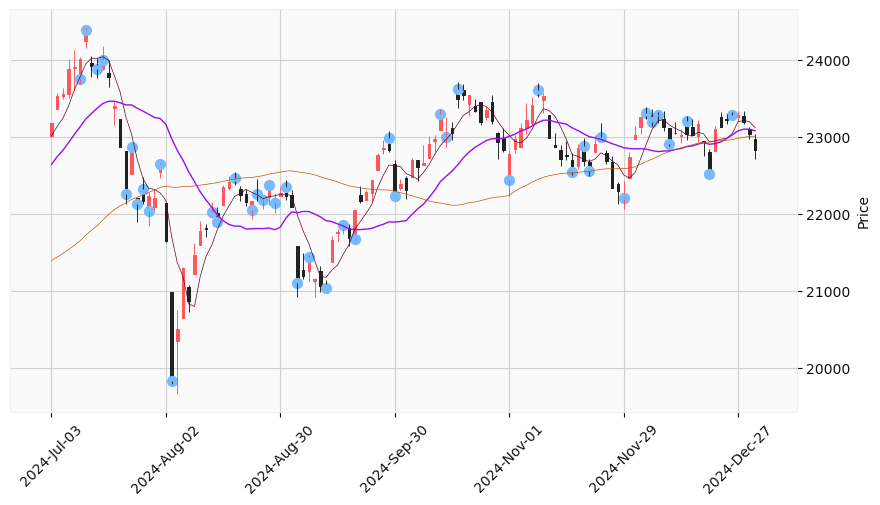

In [4]:
# 偵測轉折點
_,_,max_min = DetectTurningPoints(df_k_line,'open_close')
pd.set_option("display.max_rows", None)
print("轉折點總筆數 ＝ {:d}".format(max_min.shape[0]))
display(max_min)

# 設定K線格式
mc = mpf.make_marketcolors(up='xkcd:light red', down='xkcd:almost black', inherit=True)
s  = mpf.make_mpf_style(base_mpf_style='yahoo', marketcolors=mc)

# 設定均線與轉折點    
turning_points_len = len(np.array(df_k_line['Close']))
turning_points = np.array([np.nan]*turning_points_len)
for point in max_min.iterrows() :
    turning_points[point[0]] = point[1]['Price']    
apds = [
    mpf.make_addplot(turning_points,type='scatter',marker='o',markersize=50,color='xkcd:sky blue'),
    mpf.make_addplot(df_sma['SMA5'],width=0.5,color='xkcd:maroon'),
    mpf.make_addplot(df_sma['SMA20'],width=1.0,color='xkcd:violet'),
    mpf.make_addplot(df_sma['SMA60'],width=0.5,color='xkcd:dark orange')
]

# 繪出K線圖
kwargs = dict(type='candle', style=s, figratio=(19,10), addplot=apds, warn_too_much_data=1100)
mpf.plot(df_k_line,**kwargs)

ＤＥＢＵＧ ： 峰到谷或谷到峰之最小間隔 ＝ 5 ， 最小化過濾器的距離參數 ＝ 2 
ＤＥＢＵＧ ： 目前索引 ＝ 19 ，波峰間隔之最小索引 ＝ 22
ＤＥＢＵＧ ： 目前索引 ＝ 35 ，波谷間隔之最小索引 ＝ 37
ＤＥＢＵＧ ： 目前索引 ＝ 41 ，波峰間隔之最小索引 ＝ 44
ＤＥＢＵＧ ： 目前索引 ＝ 60 ，波谷間隔之最小索引 ＝ 64
ＤＥＢＵＧ ： 目前索引 ＝ 75 ，波谷間隔之最小索引 ＝ 76
ＤＥＢＵＧ ： 目前索引 ＝ 100 ，波谷間隔之最小索引 ＝ 101
ＤＥＢＵＧ ： 目前索引 ＝ 108 ，波谷間隔之最小索引 ＝ 109
轉折點總筆數 ＝ 11


,Date,Price,Type
DateIndex,,,
6,2024-07-11,24390.03,HI
21,2024-08-05,19830.88,LO
32,2024-08-20,22464.07,HI
48,2024-09-11,21031.00,LO
71,2024-10-18,23620.57,HI
80,2024-11-01,22438.93,LO
85,2024-11-08,23608.11,HI
91,2024-11-18,22546.54,LO
104,2024-12-05,23308.29,HI


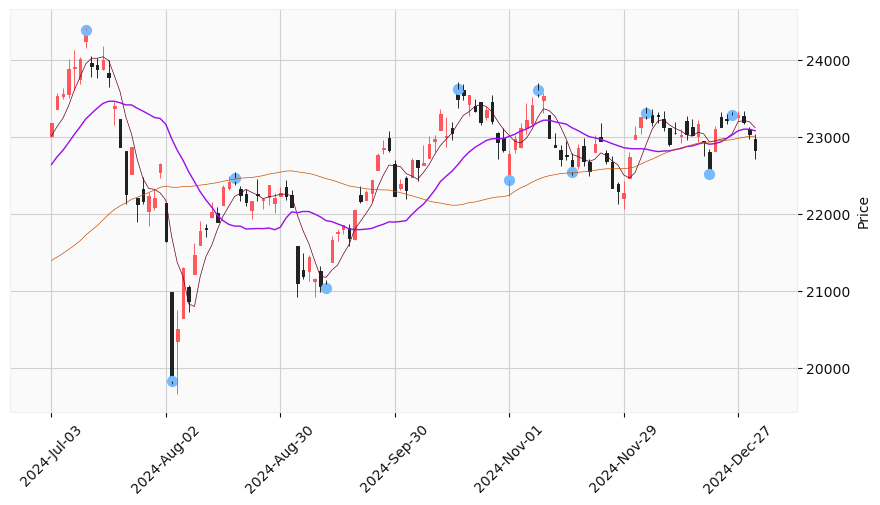

In [6]:
# 偵測轉折點
_,_,max_min = DetectTurningPoints(df_k_line,'open_close',interval=5)
pd.set_option("display.max_rows", None)
print("轉折點總筆數 ＝ {:d}".format(max_min.shape[0]))
display(max_min)

# 設定K線格式
mc = mpf.make_marketcolors(up='xkcd:light red', down='xkcd:almost black', inherit=True)
s  = mpf.make_mpf_style(base_mpf_style='yahoo', marketcolors=mc)

# 設定均線與轉折點    
turning_points_len = len(np.array(df_k_line['Close']))
turning_points = np.array([np.nan]*turning_points_len)
for point in max_min.iterrows() :
    turning_points[point[0]] = point[1]['Price']    
apds = [
    mpf.make_addplot(turning_points,type='scatter',marker='o',markersize=50,color='xkcd:sky blue'),
    mpf.make_addplot(df_sma['SMA5'],width=0.5,color='xkcd:maroon'),
    mpf.make_addplot(df_sma['SMA20'],width=1.0,color='xkcd:violet'),
    mpf.make_addplot(df_sma['SMA60'],width=0.5,color='xkcd:dark orange')
]

# 繪出K線圖
kwargs = dict(type='candle', style=s, figratio=(19,10), addplot=apds, warn_too_much_data=1100)
mpf.plot(df_k_line,**kwargs)